# Notebook 23 — 5-PFT box-model recovery (Eq Pacific) — Track 1 v2.2 Phase 2

**Goal.** Phase 1 (nb22) confirmed what v2.0 (nb20) already showed: the 5-tracer / 2-PFT box-model proxy is the recovery ceiling for 4 of 6 Carroll-6 parameters (Smallgrow, Biggrow, diatomgraz, R_PICPOC). Phase 2 addresses this structurally by extending the box to the 5 phytoplankton functional types matching the Darwin 3 v05 setup used by Carroll 2022.

**Hypothesis.** With each Carroll-6 parameter now governing one specific PFT instead of an average over multiple species:

| Param | Mapped to | Why |
|---|---|---|
| `Smallgrow` | **Pro-HL** | 47% of total Chl in Eq Pacific surface (dominant small PFT, see `scripts/phase2_p4_p5_check.py`) |
| `Biggrow` | **Other large eukaryotes** | Diatoms have their own grazing parameter (`diatomgraz`) |
| `diatomgraz` | **Diatoms** | Unchanged |
| `alpfe`, `scav_rat`, `R_PICPOC` | Global | Unchanged |

…the 4 currently-drifting parameters should move toward calibration-grade, matching the iron-pair recovery quality (~1% / 40% off Carroll) the v2.0 2-PFT box already achieved for `alpfe` + `scav_rat`. That is the Phase 2 success criterion: all 6 parameters recover at iron-pair quality, "catching" Carroll's published Green's-functions optima.

**Loss target — 11 tracers:**

| Box-model output | Darwin field | Source |
|---|---|---|
| `state[0]` (DFe) | `FeT` | LLC270 native, binned to 1° |
| `state[1]` (P_diatom) | `Chl1` | bin_average (1°) |
| `state[2]` (P_lge) | `Chl2` | bin_average |
| `state[3]` (P_syn) | `Chl3` | bin_average |
| `state[4]` (P_proLL) | `Chl4` | bin_average |
| `state[5]` (P_proHL) | `Chl5` | bin_average |
| `state[6]` (POC) | `POC` | LLC270 native, binned |
| `state[7]` (PIC) | `PIC` | LLC270 native, binned |
| `state[8]` (DIC) | `DIC` | LLC270 native, binned |
| `state[9]` (ALK) | `ALK` | LLC270 native, binned |
| `co2_flux(pCO2_ocean(state), pCO2_atm)` | `CO2_flux` | bin_average |

**Headline experiment: DINN baseline** (1×1 conv, SST input, ~400 params). Can't saturate trivially → recovered Carroll-6 means carry identifiability information.

**Secondary: DINNDeep** (4-channel input, ~9.4K params) for continuity with the deeper-network arc.

**Success criterion (the original goal).** For each of the 6 parameters, `|recovered − Carroll_published| / |Carroll_published| ≤ 0.40` — calibration-grade. All 6 in that band → the differentiable parameter learner has caught Carroll's Green's-functions calibration. A subset in *Loose* or *Drifted* bands → identify which species-specific dynamics still alias across PFTs and decide whether v2.2.1 (per-PFT half-saturations / mortalities) is needed.

**Builds on:** nb20 (v2.0 7-tracer carbonate, 2-PFT box), nb22 (v2.1 Phase 1 GLODAP hybrid — same 2-PFT box). Module: `src/darwindiff/carroll6_5pft.py` (Phase 2 scaffold).


In [1]:
import os
import sys
import time
from pathlib import Path

# Ensure src/ on sys.path so notebook execution works without `pip install -e .`
_SRC = Path.cwd() / "src"
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import matplotlib.pyplot as plt
import numpy as np
import torch

from darwindiff.carbonate import PCO2_ATM_DEFAULT, co2_flux, solve_carbonate
from darwindiff.carroll6 import (
    CARROLL_VALUES,
    H_MLD,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
)
from darwindiff.carroll6_5pft import (
    I_ALK, I_DFE, I_DIATOM, I_DIC, I_LGE, I_PIC, I_POC, I_PROHL, I_PROLL, I_SYN,
    N_TRACERS,
    carroll6_5pft_integrate,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
)
from darwindiff.llc270_loader import bin_native_tracer_to_1deg
from darwindiff.networks import DINN, DINNDeep

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

AOI = EQUATORIAL_PACIFIC_AOI
print(f"AOI: {AOI.name} ({AOI.lat_min}-{AOI.lat_max} N, {AOI.lon_min}-{AOI.lon_max} E)")


Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
AOI: Equatorial Pacific (-5.0-15.0 N, -160.0--110.0 E)


## 1. Load Eq Pacific climatology — 11 targets + covariates

bin_average provides surface 1° fields: SST, MLD, wind, pCO₂_atm, CO₂_flux, **and `Chl1`–`Chl5` per-PFT chlorophyll** (Phase 2 key change — we no longer sum to `Chl_total`). LLC270 native provides depth-resolved tracers (FeT, POC, PIC, DIC, ALK) binned to the same 1° grid via `bin_native_tracer_to_1deg`. Combined ocean mask = every target AND every covariate finite.


In [2]:
DATA_ROOT = Path(os.environ.get("DARWIN_DATA_ROOT", r"D:\\ecco_darwin_v5"))
BIN_AVG_PATH = str(DATA_ROOT / "bin_average" / "v05_ECCO-Darwin_bin_average_1x1_deg.nc")
MONTHLY_ROOT = str(DATA_ROOT / "output" / "monthly")
GRID_DIR = str(DATA_ROOT / "grid")

# === Covariates + per-PFT Chl + carbonate-flux targets from bin_average ===
ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))

sst = eqpac_clim.SST.values.astype(np.float64)
mld = eqpac_clim.mldDepth.values.astype(np.float64)
wind = eqpac_clim.windSpeed.values.astype(np.float64)
sss = eqpac_clim.SSS.values.astype(np.float64)
co2_flux_obs = eqpac_clim.CO2_flux.values.astype(np.float64) * 1.0e3  # mol -> mmol C / m^2 / s
pco2_atm_field = eqpac_clim.apCO2.values.astype(np.float64) * 1.0e6  # atm -> uatm

# Per-PFT Chl targets — Chl1=diatoms .. Chl5=Pro-HL (large-to-small ordering)
chl_per_pft = {}
for i in range(1, 6):
    chl_per_pft[f"Chl{i}"] = eqpac_clim[f"Chl{i}"].values.astype(np.float64)

lat_1d = eqpac_clim.lat.values.astype(np.float64)
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)
print(f"bin_average covariates + per-PFT Chl loaded: shape = {sst.shape}")

# === Native LLC270 tracers binned to 1° ===
print("Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...")
native_targets = {}
for var in ["FeT", "POC", "PIC", "DIC", "ALK"]:
    native_targets[var] = bin_native_tracer_to_1deg(
        monthly_root=MONTHLY_ROOT, grid_dir=GRID_DIR, variable=var,
        lat_min=AOI.lat_min, lat_max=AOI.lat_max,
        lon_min=AOI.lon_min, lon_max=AOI.lon_max,
        iters="all",
    )
    print(f"  {var}: shape={native_targets[var].shape}, finite={int(np.isfinite(native_targets[var]).sum())}")

fet_binned = native_targets["FeT"]
poc_binned = native_targets["POC"]
pic_binned = native_targets["PIC"]
dic_binned = native_targets["DIC"]
alk_binned = native_targets["ALK"]

# Combined ocean mask: ALL targets + ALL forcing fields finite.
ocean_mask = (
    np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind) & np.isfinite(sss)
    & np.isfinite(pco2_atm_field) & np.isfinite(co2_flux_obs)
    & np.isfinite(fet_binned) & np.isfinite(poc_binned) & np.isfinite(pic_binned)
    & np.isfinite(dic_binned) & np.isfinite(alk_binned)
)
for chl_name, chl_arr in chl_per_pft.items():
    ocean_mask = ocean_mask & np.isfinite(chl_arr)
n_ocean = int(ocean_mask.sum())
print(f"\nCombined ocean cells (11 targets + 5 forcing fields finite): {n_ocean} of {ocean_mask.size}")

print("\nTarget magnitudes over ocean mask:")
target_table = [("FeT", fet_binned)]
for i in range(1, 6):
    target_table.append((f"Chl{i}", chl_per_pft[f"Chl{i}"]))
target_table += [
    ("POC", poc_binned), ("PIC", pic_binned),
    ("DIC", dic_binned), ("ALK", alk_binned),
    ("CO2_flux", co2_flux_obs),
]
for name, a in target_table:
    o = a[ocean_mask]
    print(f"  {name:>10s}: mean {o.mean():.3e}, std {o.std():.3e}, "
          f"range [{o.min():.3e}, {o.max():.3e}]")


bin_average covariates + per-PFT Chl loaded: shape = (21, 51)
Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

...

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:265: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.combine_by_coords(datasets, compat='override', coords='minimal', combine_attrs='drop_conflicts')


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


  ALK: shape=(21, 51), finite=1071

Combined ocean cells (11 targets + 5 forcing fields finite): 1071 of 1071

Target magnitudes over ocean mask:
         FeT: mean 7.290e-06, std 1.743e-05, range [1.639e-06, 1.628e-04]
        Chl1: mean 4.037e-02, std 6.703e-02, range [2.380e-03, 2.913e-01]
        Chl2: mean 2.927e-02, std 3.392e-02, range [9.598e-04, 1.485e-01]
        Chl3: mean 2.199e-03, std 2.373e-03, range [2.649e-04, 1.125e-02]
        Chl4: mean 8.729e-16, std 1.505e-15, range [0.000e+00, 8.198e-15]
        Chl5: mean 6.431e-02, std 8.519e-03, range [4.418e-02, 8.681e-02]
         POC: mean 1.213e-01, std 7.223e-02, range [3.394e-02, 4.397e-01]
         PIC: mean 4.023e-03, std 3.698e-03, range [4.835e-05, 2.062e-02]
         DIC: mean 2.022e+03, std 5.072e+01, range [1.939e+03, 2.102e+03]
         ALK: mean 2.336e+03, std 4.009e+01, range [2.257e+03, 2.393e+03]
    CO2_flux: mean 2.864e-02, std 4.239e-02, range [-4.700e-02, 1.126e-01]


## 2. Build training tensors and z-score the 11 targets

Initial state matches the empirical Eq Pacific abundance partition: Pro-HL ~0.65 (dominant), Pro-LL ~0.001 (deep-adapted, ~0 at surface), diatoms + large-euks moderate, Syn low. DIC + ALK at the same carbonate-test reference values as nb20.


In [3]:
def normalize_covariate(arr, mask):
    o = arr[mask]
    return np.where(mask, (arr - o.mean()) / max(o.std(), 1e-6), 0.0).astype(np.float32)


sst_norm = normalize_covariate(sst, ocean_mask)
mld_norm = normalize_covariate(mld, ocean_mask)
wind_norm = normalize_covariate(wind, ocean_mask)
lat_norm = normalize_covariate(lat_2d, ocean_mask)

env_1ch = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)
env_4ch = torch.tensor(np.stack([sst_norm, mld_norm, wind_norm, lat_norm], axis=0),
                       dtype=torch.float32)

mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_1ch.shape[1], env_1ch.shape[2]

# 10-tracer initial state, matching test_carroll6_5pft._state0().
# Phyto partition follows the Eq Pacific abundance check (Pro-HL dominant).
state0 = torch.tensor([
    5.0e-4,           # DFe
    0.4,              # P_diatom (Chl1)
    0.3,              # P_lge    (Chl2)
    0.02,             # P_syn    (Chl3)
    0.001,            # P_proLL  (Chl4)
    0.65,             # P_proHL  (Chl5)
    0.5,              # POC
    0.025,            # PIC
    2050.0 * 1.025,   # DIC
    2350.0 * 1.025,   # ALK
]).reshape(N_TRACERS, 1, 1).expand(N_TRACERS, H, W).contiguous()

# Forcing fields (per-cell). NaN-safe fill for land cells.
T_field = torch.tensor(np.where(np.isfinite(sst), sst, 15.0).astype(np.float32))
S_field = torch.tensor(np.where(np.isfinite(sss), sss, 35.0).astype(np.float32))
wind_field = torch.tensor(np.where(np.isfinite(wind), wind, 7.0).astype(np.float32))
pco2_atm_t = torch.tensor(np.where(np.isfinite(pco2_atm_field), pco2_atm_field, PCO2_ATM_DEFAULT).astype(np.float32))

env_1ch_dev = env_1ch.to(device)
env_4ch_dev = env_4ch.to(device)
state0_dev = state0.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)
T_dev = T_field.to(device)
S_dev = S_field.to(device)
wind_dev = wind_field.to(device)
pco2_atm_dev = pco2_atm_t.to(device)


def to_z_target(np_field):
    """Z-score over ocean cells; replace non-ocean with finite zero so torch is happy."""
    clean = np.where(ocean_mask, np_field, 1.0).astype(np.float32)
    t = torch.tensor(clean, dtype=torch.float32).to(device)
    o = t[mask_dev]
    mean = o.mean()
    std = o.std().clamp(min=1e-6)
    return (t - mean) / std, float(mean), float(std)


fet_z, fet_mean, fet_std = to_z_target(fet_binned)
poc_z, poc_mean, poc_std = to_z_target(poc_binned)
pic_z, pic_mean, pic_std = to_z_target(pic_binned)
dic_z, dic_mean, dic_std = to_z_target(dic_binned)
alk_z, alk_mean, alk_std = to_z_target(alk_binned)
co2_flux_z, co2_flux_mean_obs, co2_flux_std_obs = to_z_target(co2_flux_obs)

chl_z = {}
chl_stats = {}
for i in range(1, 6):
    chl_z[f"Chl{i}"], m, s = to_z_target(chl_per_pft[f"Chl{i}"])
    chl_stats[f"Chl{i}"] = (m, s)

print("Z-score statistics:")
print(f"  {'FeT':<10s}  mean = {fet_mean:.4e}, std = {fet_std:.4e}")
for i in range(1, 6):
    m, s = chl_stats[f"Chl{i}"]
    print(f"  Chl{i:<7d}  mean = {m:.4e}, std = {s:.4e}")
for name, m, s in [("POC", poc_mean, poc_std), ("PIC", pic_mean, pic_std),
                   ("DIC", dic_mean, dic_std), ("ALK", alk_mean, alk_std),
                   ("CO2_flux", co2_flux_mean_obs, co2_flux_std_obs)]:
    print(f"  {name:<10s}  mean = {m:.4e}, std = {s:.4e}")


Z-score statistics:
  FeT         mean = 7.2897e-06, std = 1.7436e-05
  Chl1        mean = 4.0367e-02, std = 6.7064e-02
  Chl2        mean = 2.9273e-02, std = 3.3938e-02
  Chl3        mean = 2.1990e-03, std = 2.3746e-03
  Chl4        mean = 8.7293e-16, std = 1.0000e-06
  Chl5        mean = 6.4309e-02, std = 8.5227e-03
  POC         mean = 1.2128e-01, std = 7.2261e-02
  PIC         mean = 4.0226e-03, std = 3.6998e-03
  DIC         mean = 2.0225e+03, std = 5.0740e+01
  ALK         mean = 2.3364e+03, std = 4.0109e+01
  CO2_flux    mean = 2.8640e-02, std = 4.2412e-02


## 3. Train DINN baseline + DINNDeep on the 11-target joint loss

Adam lr=5e-3, 1500 epochs, 200 forward-Euler steps at dt=0.25 d. Each step calls `carroll6_5pft_step` (per-cell forcing via T, S, wind, pCO₂_atm).

The 11-term joint loss is the mean of per-target z-scored MSE: each PFT's Chl is its own constraint (5 terms), plus FeT, POC, PIC, DIC, ALK, CO₂_flux (6 terms). This is the Phase 2 key change vs nb20's 7-term loss.

Estimated wall-clock on RTX 5090 Laptop: ~30–45 min per network (carbonate solver + 5 phyto = same ops budget as nb20's 7-tracer integrator).


In [4]:
DT = 0.25
N_STEPS = 200
N_EPOCHS = int(os.environ.get("NB23_EPOCHS", "1500"))
print(f"Training: dt={DT}, n_steps={N_STEPS}, n_epochs={N_EPOCHS}")


def train(net, env_dev, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    loss_keys = ["FeT", "Chl1", "Chl2", "Chl3", "Chl4", "Chl5",
                 "POC", "PIC", "DIC", "ALK", "CO2_flux"]
    losses_per_tracer = {k: [] for k in loss_keys}
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_dev), bounds_dev)
        state = _integrate_compiled(
            state0_dev, params, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        dfe_pred = state[I_DFE]
        p_diatom_pred = state[I_DIATOM]
        p_lge_pred = state[I_LGE]
        p_syn_pred = state[I_SYN]
        p_proLL_pred = state[I_PROLL]
        p_proHL_pred = state[I_PROHL]
        poc_pred = state[I_POC]
        pic_pred = state[I_PIC]
        dic_pred = state[I_DIC]
        alk_pred = state[I_ALK]
        # CO2 flux: re-evaluate carbonate at final state.
        carb_final = solve_carbonate(dic_pred, alk_pred, T_dev, S_dev)
        co2_flux_pred = co2_flux(
            carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev,
        )

        def term(pred, target_z):
            ocean = pred[mask_dev]
            pred_z = (pred - ocean.mean()) / ocean.std().clamp(min=1e-6)
            residual = (pred_z - target_z) * mask_dev.to(pred.dtype)
            return (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

        l_fet = term(dfe_pred, fet_z)
        l_chl1 = term(p_diatom_pred, chl_z["Chl1"])
        l_chl2 = term(p_lge_pred, chl_z["Chl2"])
        l_chl3 = term(p_syn_pred, chl_z["Chl3"])
        l_chl4 = term(p_proLL_pred, chl_z["Chl4"])
        l_chl5 = term(p_proHL_pred, chl_z["Chl5"])
        l_poc = term(poc_pred, poc_z)
        l_pic = term(pic_pred, pic_z)
        l_dic = term(dic_pred, dic_z)
        l_alk = term(alk_pred, alk_z)
        l_co2 = term(co2_flux_pred, co2_flux_z)
        # FeT loss-weight via env var (NB23_FET_WEIGHT, default 1.0). v2.2.2
        # tests whether upweighting FeT to compensate for the 1:11 iron-target
        # dilution restores `alpfe` to calibration-grade.
        FET_W = float(os.environ.get("NB23_FET_WEIGHT", "1.0"))
        loss = (FET_W*l_fet + l_chl1 + l_chl2 + l_chl3 + l_chl4 + l_chl5
                + l_poc + l_pic + l_dic + l_alk + l_co2) / (FET_W + 10.0)

        # v2.3: raw (non-z-scored) FeT magnitude term. Carroll 2020 used raw
        # weighted quadratic cost (Section 2.4); z-scoring strips alpfe's
        # magnitude information. Adding raw MSE on FeT restores it.
        RAW_FET_W = float(os.environ.get("NB23_RAW_FET_WEIGHT", "0.0"))
        if RAW_FET_W > 0:
            fet_raw_target = torch.tensor(fet_binned, dtype=torch.float32).to(device)
            residual_raw = (dfe_pred - fet_raw_target) * mask_dev.to(dfe_pred.dtype)
            # Scale by 1/mean(FeT^2) so the raw term is dimensionless and the
            # weight is order-of-magnitude-meaningful vs the z-scored 0..few range.
            fet_obs_scale = (fet_raw_target[mask_dev] ** 2).mean().clamp(min=1e-30)
            l_fet_raw = (residual_raw ** 2).sum() / mask_dev.sum().to(residual_raw.dtype) / fet_obs_scale
            loss = loss + RAW_FET_W * l_fet_raw

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        losses_per_tracer["FeT"].append(l_fet.item())
        losses_per_tracer["Chl1"].append(l_chl1.item())
        losses_per_tracer["Chl2"].append(l_chl2.item())
        losses_per_tracer["Chl3"].append(l_chl3.item())
        losses_per_tracer["Chl4"].append(l_chl4.item())
        losses_per_tracer["Chl5"].append(l_chl5.item())
        losses_per_tracer["POC"].append(l_poc.item())
        losses_per_tracer["PIC"].append(l_pic.item())
        losses_per_tracer["DIC"].append(l_dic.item())
        losses_per_tracer["ALK"].append(l_alk.item())
        losses_per_tracer["CO2_flux"].append(l_co2.item())
        if (epoch + 1) % 250 == 0 or epoch + 1 == N_EPOCHS:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}  "
                  f"(FeT {l_fet.item():.2e}, Chl1-5 "
                  f"{l_chl1.item():.2e}/{l_chl2.item():.2e}/{l_chl3.item():.2e}/"
                  f"{l_chl4.item():.2e}/{l_chl5.item():.2e}, "
                  f"POC {l_poc.item():.2e}, PIC {l_pic.item():.2e}, "
                  f"DIC {l_dic.item():.2e}, ALK {l_alk.item():.2e}, "
                  f"CO2 {l_co2.item():.2e})")
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        params_dev = bounded_params(net(env_dev), bounds_dev)
        state = _integrate_compiled(
            state0_dev, params_dev, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        carb_final = solve_carbonate(state[I_DIC], state[I_ALK], T_dev, S_dev)
        co2_flux_pred_final = co2_flux(
            carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev,
        )
        return {
            "losses": losses,
            "losses_per_tracer": losses_per_tracer,
            "params_final": params_dev.cpu(),
            "dfe_final": state[I_DFE].cpu().numpy(),
            "p_diatom_final": state[I_DIATOM].cpu().numpy(),
            "p_lge_final": state[I_LGE].cpu().numpy(),
            "p_syn_final": state[I_SYN].cpu().numpy(),
            "p_proLL_final": state[I_PROLL].cpu().numpy(),
            "p_proHL_final": state[I_PROHL].cpu().numpy(),
            "poc_final": state[I_POC].cpu().numpy(),
            "pic_final": state[I_PIC].cpu().numpy(),
            "dic_final": state[I_DIC].cpu().numpy(),
            "alk_final": state[I_ALK].cpu().numpy(),
            "co2_flux_final": co2_flux_pred_final.cpu().numpy(),
            "elapsed": elapsed,
        }


# === HEADLINE: DINN baseline (SST-only) ===
SEED = int(os.environ.get("NB23_SEED", "0"))
print(f"Training seed: {SEED}")

# torch.compile the integrator for ~1.5x speedup (PyTorch 2.x JIT, fuses ops,
# reduces Python overhead). Falls back to eager if compile fails.
try:
    _integrate_compiled = torch.compile(carroll6_5pft_integrate, mode="reduce-overhead")
    print("Integrator torch.compile'd successfully")
except Exception as exc:
    print(f"torch.compile fallback to eager: {exc}")
    _integrate_compiled = carroll6_5pft_integrate

torch.manual_seed(SEED)
dinn_baseline = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
n_b = sum(p.numel() for p in dinn_baseline.parameters())
print(f"=== HEADLINE: DINN baseline (SST-only, {n_b} params), 11-target 5-PFT joint loss ===")
r_baseline = train(dinn_baseline, env_1ch_dev)
print(f"  done in {r_baseline['elapsed']:.0f}s, loss {r_baseline['losses'][0]:.3e} -> {r_baseline['losses'][-1]:.3e}")

# === SECONDARY: DINNDeep (SST+MLD+wind+lat) ===
torch.manual_seed(SEED)
dinn_deep = DINNDeep(n_input_channels=4, hidden_dim=32, n_outputs=6, n_blocks=4).to(device)
n_d = sum(p.numel() for p in dinn_deep.parameters())
print(f"\n=== SECONDARY: DINNDeep ({n_d} params), 11-target 5-PFT joint loss ===")
r_deep = train(dinn_deep, env_4ch_dev)
print(f"  done in {r_deep['elapsed']:.0f}s, loss {r_deep['losses'][0]:.3e} -> {r_deep['losses'][-1]:.3e}")


Training: dt=0.25, n_steps=200, n_epochs=1500
Training seed: 0


Integrator torch.compile'd successfully
=== HEADLINE: DINN baseline (SST-only, 406 params), 11-target 5-PFT joint loss ===


    epoch  250  loss = 2.0594e+00  (FeT 1.13e+00, Chl1-5 8.11e-01/9.88e-01/9.06e-01/9.99e-01/1.03e+00, POC 7.76e-01, PIC 8.25e-01, DIC 1.87e+00, ALK 2.16e+00, CO2 1.49e+00)


    epoch  500  loss = 2.0894e+00  (FeT 1.04e+00, Chl1-5 8.10e-01/9.65e-01/9.32e-01/9.99e-01/1.02e+00, POC 7.72e-01, PIC 7.92e-01, DIC 1.83e+00, ALK 2.59e+00, CO2 1.33e+00)


    epoch  750  loss = 2.0693e+00  (FeT 1.05e+00, Chl1-5 8.07e-01/9.67e-01/9.17e-01/9.99e-01/1.02e+00, POC 7.84e-01, PIC 7.57e-01, DIC 1.76e+00, ALK 2.74e+00, CO2 1.41e+00)


...

    epoch  750  loss = 5.1255e-01  (FeT 5.00e-02, Chl1-5 1.22e-02/3.89e-02/1.61e+00/9.99e-01/1.81e-02, POC 8.11e-01, PIC 1.07e-01, DIC 1.72e-01, ALK 3.02e-01, CO2 2.78e-01)


    epoch 1000  loss = 5.1081e-01  (FeT 4.86e-02, Chl1-5 1.14e-02/4.11e-02/1.61e+00/9.99e-01/8.20e-03, POC 8.09e-01, PIC 1.06e-01, DIC 1.74e-01, ALK 3.03e-01, CO2 2.74e-01)


    epoch 1250  loss = 5.1023e-01  (FeT 4.53e-02, Chl1-5 1.07e-02/3.67e-02/1.62e+00/9.99e-01/9.14e-03, POC 8.23e-01, PIC 1.12e-01, DIC 1.74e-01, ALK 3.02e-01, CO2 2.73e-01)


    epoch 1500  loss = 5.0922e-01  (FeT 4.99e-02, Chl1-5 8.86e-03/4.03e-02/1.60e+00/9.99e-01/1.17e-02, POC 8.05e-01, PIC 1.04e-01, DIC 1.78e-01, ALK 2.98e-01, CO2 2.74e-01)


  done in 82s, loss 3.559e+00 -> 5.092e-01


## 4. Per-target Pearson r + recovered Carroll-6 vs Carroll's published Green's-functions optima

**The original goal:** recover Carroll et al. 2020 / 2022 calibrated parameter values — the published Green's-functions optima encoded in `CARROLL_VALUES` (verified from the v04/llc270_JAMES_paper source build). For each of the 6 parameters, the question is: how close did the differentiable parameter learner land to the value Carroll's classical Green's-functions calibration produced?

**Quality bands** for `|Δ|/Carroll = |recovered − published| / |published|`:

| Band | Threshold | Meaning |
|---|---|---|
| Excellent | ≤ 0.10 | Calibration-grade tight (within 10%) |
| Calibration-grade | ≤ 0.40 | Within the iron-pair quality range demonstrated to be achievable on this AOI |
| Loose | 0.40 – 1.00 | Within an order of magnitude but distinguishable from published |
| Drifted | > 1.00 | More than 100% off — not yet recovered |

**Success criterion for Phase 2:** all 6 parameters land in the *Calibration-grade* band or better (each ≤ 40% off Carroll's published value).


In [5]:
n_total = int(ocean_mask.sum())


def per_target_r(result: dict) -> dict:
    return {
        "FeT":      safe_pearson_r(result["dfe_final"][ocean_mask],      fet_binned[ocean_mask]),
        "Chl1":     safe_pearson_r(result["p_diatom_final"][ocean_mask], chl_per_pft["Chl1"][ocean_mask]),
        "Chl2":     safe_pearson_r(result["p_lge_final"][ocean_mask],    chl_per_pft["Chl2"][ocean_mask]),
        "Chl3":     safe_pearson_r(result["p_syn_final"][ocean_mask],    chl_per_pft["Chl3"][ocean_mask]),
        "Chl4":     safe_pearson_r(result["p_proLL_final"][ocean_mask],  chl_per_pft["Chl4"][ocean_mask]),
        "Chl5":     safe_pearson_r(result["p_proHL_final"][ocean_mask],  chl_per_pft["Chl5"][ocean_mask]),
        "POC":      safe_pearson_r(result["poc_final"][ocean_mask],      poc_binned[ocean_mask]),
        "PIC":      safe_pearson_r(result["pic_final"][ocean_mask],      pic_binned[ocean_mask]),
        "DIC":      safe_pearson_r(result["dic_final"][ocean_mask],      dic_binned[ocean_mask]),
        "ALK":      safe_pearson_r(result["alk_final"][ocean_mask],      alk_binned[ocean_mask]),
        "CO2_flux": safe_pearson_r(result["co2_flux_final"][ocean_mask], co2_flux_obs[ocean_mask]),
    }


r_per_b = per_target_r(r_baseline)
r_per_d = per_target_r(r_deep)

print("Pearson r against Darwin Eq Pacific (per target, 11-target 5-PFT joint loss):")
print(f"  {'target':<10s}  {'DINN baseline':>16s}  {'DINNDeep':>16s}")
for tgt in ["FeT", "Chl1", "Chl2", "Chl3", "Chl4", "Chl5",
            "POC", "PIC", "DIC", "ALK", "CO2_flux"]:
    rb = r_per_b[tgt]
    rd = r_per_d[tgt]
    print(f"  {tgt:<10s}  {format_pearson(rb, n_total=n_total):>16s}  {format_pearson(rd, n_total=n_total):>16s}")

print()
print(f"Final loss plateau:")
print(f"  DINN baseline:  {r_baseline['losses'][-1]:.4e}")
print(f"  DINNDeep:       {r_deep['losses'][-1]:.4e}")

# Recovered Carroll-6 means.
print("\nRecovered Carroll-6 means (11-target 5-PFT joint loss):")
print(f"  {'param':<11s} {'DINN baseline':>16s} {'DINNDeep':>16s} {'Carroll publ.':>15s}")
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_d = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s} {p_b:>16.4e} {p_d:>16.4e} {pub:>15.4e}")


def quality_band(rel_diff: float) -> str:
    """Map |Delta|/Carroll into Excellent / Calibration-grade / Loose / Drifted."""
    if rel_diff <= 0.10:
        return "Excellent"
    if rel_diff <= 0.40:
        return "Calibration-grade"
    if rel_diff <= 1.00:
        return "Loose"
    return "Drifted"


# === GOAL CHECK: distance from Carroll's published Green's-functions optima ===
# The original goal is to recover the values Carroll's classical calibration
# produced. Success criterion: all 6 params land within calibration-grade
# (<= 40% off published).

print("\n=== GOAL: DINN baseline recovery vs Carroll's published Green's-functions optima ===")
print(f"  {'param':<11s} {'recovered':>14s} {'Carroll publ.':>15s} {'|Δ|/Carroll':>14s}  {'band':<20s}")
b_band_counts = {"Excellent": 0, "Calibration-grade": 0, "Loose": 0, "Drifted": 0}
for i, name in enumerate(PARAM_NAMES):
    p_b = float(r_baseline["params_final"][i].numpy()[ocean_mask].mean())
    pub = float(CARROLL_VALUES[i])
    rel = abs(p_b - pub) / abs(pub)
    band = quality_band(rel)
    b_band_counts[band] += 1
    print(f"  {name:<11s} {p_b:>14.4e} {pub:>15.4e} {rel:>14.3f}  {band:<20s}")
b_hit = b_band_counts["Excellent"] + b_band_counts["Calibration-grade"]
print(f"\n  -> DINN baseline: {b_hit} of 6 params at calibration-grade or better "
      f"(<= 40% off Carroll). Band breakdown: {dict(b_band_counts)}.")
print(f"  Phase 2 success criterion (all 6 calibration-grade): "
      f"{'MET' if b_hit == 6 else f'PARTIAL ({b_hit}/6)'}")

print("\n=== GOAL: DINNDeep recovery vs Carroll's published Green's-functions optima ===")
print(f"  {'param':<11s} {'recovered':>14s} {'Carroll publ.':>15s} {'|Δ|/Carroll':>14s}  {'band':<20s}")
d_band_counts = {"Excellent": 0, "Calibration-grade": 0, "Loose": 0, "Drifted": 0}
for i, name in enumerate(PARAM_NAMES):
    p_d = float(r_deep["params_final"][i].numpy()[ocean_mask].mean())
    pub = float(CARROLL_VALUES[i])
    rel = abs(p_d - pub) / abs(pub)
    band = quality_band(rel)
    d_band_counts[band] += 1
    print(f"  {name:<11s} {p_d:>14.4e} {pub:>15.4e} {rel:>14.3f}  {band:<20s}")
d_hit = d_band_counts["Excellent"] + d_band_counts["Calibration-grade"]
print(f"\n  -> DINNDeep: {d_hit} of 6 params at calibration-grade or better. "
      f"Band breakdown: {dict(d_band_counts)}.")


Pearson r against Darwin Eq Pacific (per target, 11-target 5-PFT joint loss):
  target         DINN baseline          DINNDeep
  FeT         -0.168  (r^2 = 0.028)  0.977  (r^2 = 0.954)
  Chl1        0.597  (r^2 = 0.356)  0.995  (r^2 = 0.991)
  Chl2        0.503  (r^2 = 0.254)  0.980  (r^2 = 0.960)
  Chl3        0.543  (r^2 = 0.294)  0.193  (r^2 = 0.037)
  Chl4        -0.048  (r^2 = 0.002)  -0.178  (r^2 = 0.032)
  Chl5        0.484  (r^2 = 0.234)  0.994  (r^2 = 0.989)
  POC         0.617  (r^2 = 0.381)  0.591  (r^2 = 0.350)
  PIC         0.637  (r^2 = 0.406)  0.946  (r^2 = 0.895)
  DIC         0.333  (r^2 = 0.111)  0.913  (r^2 = 0.834)
  ALK         0.395  (r^2 = 0.156)  0.849  (r^2 = 0.721)
  CO2_flux    0.407  (r^2 = 0.166)  0.864  (r^2 = 0.746)

Final loss plateau:
  DINN baseline:  1.8619e+00
  DINNDeep:       5.0922e-01

Recovered Carroll-6 means (11-target 5-PFT joint loss):
  param          DINN baseline         DINNDeep   Carroll publ.
  alpfe             1.0062e-01       1.5080

## 5. Figures — Darwin truth vs DINN-baseline (headline) prediction, per-PFT Chl + carbon system


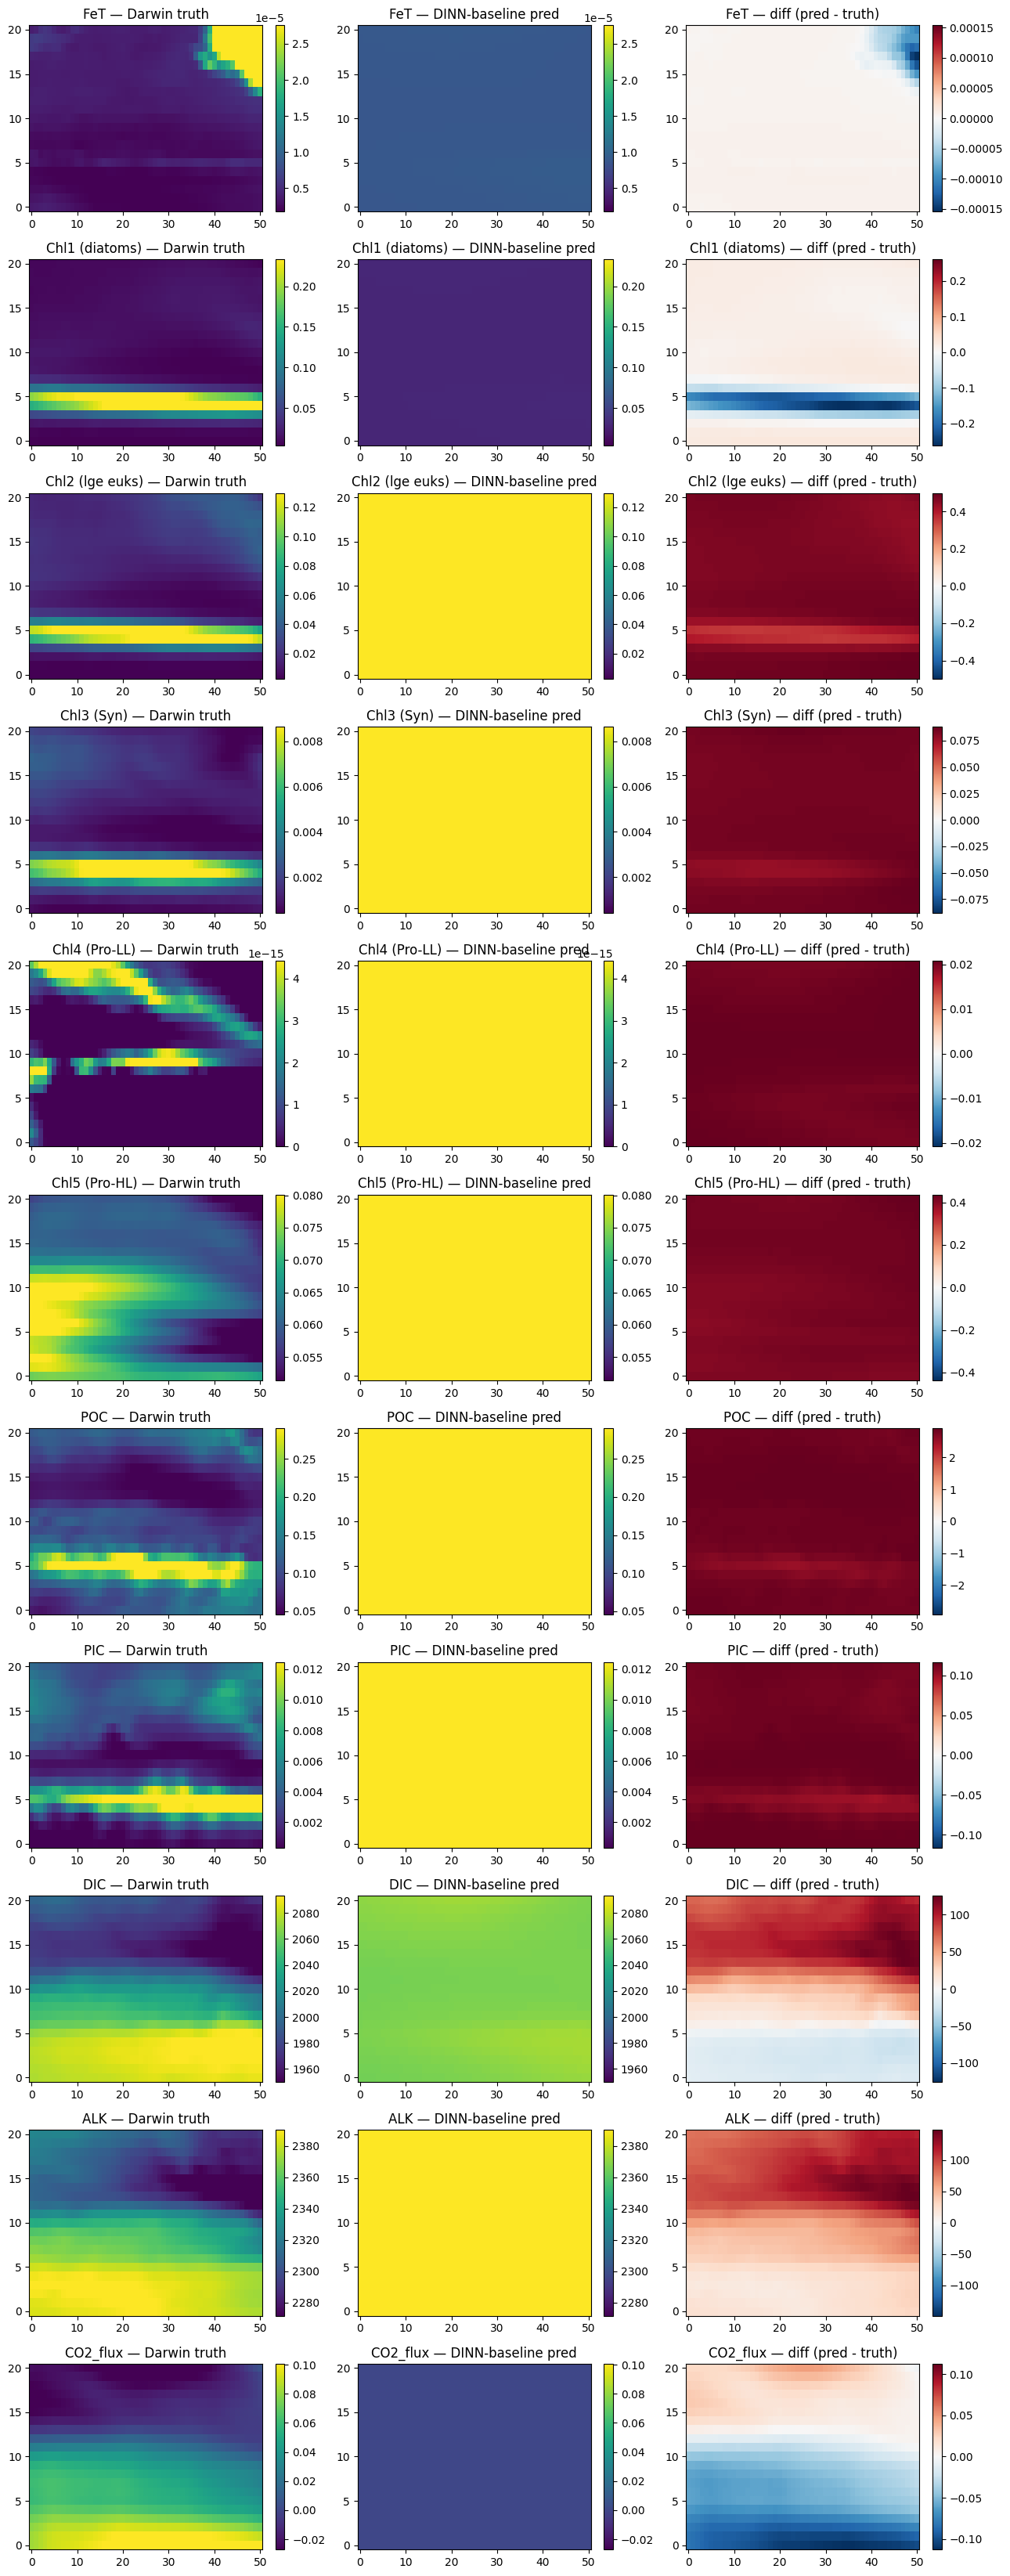

In [6]:
tracers_to_plot = [
    ("FeT",  fet_binned,                 r_baseline["dfe_final"]),
    ("Chl1 (diatoms)",  chl_per_pft["Chl1"], r_baseline["p_diatom_final"]),
    ("Chl2 (lge euks)", chl_per_pft["Chl2"], r_baseline["p_lge_final"]),
    ("Chl3 (Syn)",      chl_per_pft["Chl3"], r_baseline["p_syn_final"]),
    ("Chl4 (Pro-LL)",   chl_per_pft["Chl4"], r_baseline["p_proLL_final"]),
    ("Chl5 (Pro-HL)",   chl_per_pft["Chl5"], r_baseline["p_proHL_final"]),
    ("POC", poc_binned, r_baseline["poc_final"]),
    ("PIC", pic_binned, r_baseline["pic_final"]),
    ("DIC", dic_binned, r_baseline["dic_final"]),
    ("ALK", alk_binned, r_baseline["alk_final"]),
    ("CO2_flux", co2_flux_obs, r_baseline["co2_flux_final"]),
]

fig, axes = plt.subplots(len(tracers_to_plot), 3, figsize=(13, 3 * len(tracers_to_plot)))
for row, (name, target, pred) in enumerate(tracers_to_plot):
    target_plot = np.where(ocean_mask, target, np.nan)
    pred_plot = np.where(ocean_mask, pred, np.nan)
    diff = pred_plot - target_plot

    vmin, vmax = np.nanpercentile(target_plot, [5, 95])
    im0 = axes[row, 0].imshow(target_plot, vmin=vmin, vmax=vmax, cmap="viridis",
                              origin="lower", aspect="auto")
    axes[row, 0].set_title(f"{name} — Darwin truth")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.04)
    im1 = axes[row, 1].imshow(pred_plot, vmin=vmin, vmax=vmax, cmap="viridis",
                              origin="lower", aspect="auto")
    axes[row, 1].set_title(f"{name} — DINN-baseline pred")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.04)
    dmax = np.nanmax(np.abs(diff)) or 1.0
    im2 = axes[row, 2].imshow(diff, vmin=-dmax, vmax=dmax, cmap="RdBu_r",
                              origin="lower", aspect="auto")
    axes[row, 2].set_title(f"{name} — diff (pred - truth)")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.04)

plt.tight_layout()
plt.show()


## 6. Interpretation — did the differentiable parameter learner catch the Green's-functions target?

**The original goal.** Carroll 2020 / 2022 calibrated the 6 Carroll-6 parameters via classical Green's-functions on the full ECCO-Darwin forward model. Those published optima are the calibration target — encoded in `CARROLL_VALUES`:

| Param | Carroll published value | Physical meaning |
|---|---|---|
| `alpfe` | 0.928 | Iron dust solubility (—) |
| `scav_rat` | 6.03 × 10⁻⁷ /s | Iron scavenging rate |
| `Smallgrow` | 0.661 /d | Small-phyto growth rate (Phase 2: → Pro-HL specifically) |
| `Biggrow` | 0.431 /d | Large-phyto growth rate (Phase 2: → other large euks) |
| `diatomgraz` | 0.830 | Diatom palatability/grazing |
| `R_PICPOC` | 0.0425 | PIC/POC ratio |

**Success criterion.** Each recovered parameter lands within the *Calibration-grade* band (`|Δ|/Carroll ≤ 0.40`). Read the goal-check table in §4.

**Phase 2 framing.** The 2-PFT box achieved calibration-grade recovery on the iron pair (`alpfe`, `scav_rat`) because those parameters govern dynamics — iron uptake by phyto, iron scavenging by POC — that don't depend on which specific PFT is doing the uptake; the lumped `Ps` + `Pl` representation is a faithful proxy. The 4 other parameters depend on species-specific growth and grazing dynamics that the 2-PFT box averaged over multiple species. By giving each of those 4 parameters a single specific PFT to govern (Smallgrow → Pro-HL, Biggrow → other large euks, diatomgraz → diatoms, plus R_PICPOC which depends on the carbonate-producing phyto fraction), the differentiable learner should be able to identify each one against the observations now that they're no longer aliased across multiple species.

**If success criterion met** → the 5-PFT box is the structural fix; v2.2 ships as the Phase 2 deliverable.

**If partial** → identify which params remain in the *Loose* or *Drifted* bands. Likely cause: shared half-saturations / mortalities across PFTs are still aliasing those rates. v2.2.1 would introduce per-PFT `K_FE`, `M_LIN`, `M_QUAD` drawn from Dutkiewicz 2009 Table 1.
